In [4]:
print("OK")

OK


In [5]:
import os

# Make sure only 4 cpus are used
os.environ["OMP_NUM_THREADS"] = "4"
os.environ["OPENBLAS_NUM_THREADS"] = "4"
os.environ["MKL_NUM_THREADS"] = "4"
os.environ["VECLIB_MAXIMUM_THREADS"] = "4"
os.environ["NUMEXPR_NUM_THREADS"] = "4"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, average_precision_score
from tqdm import tqdm

plt.rcParams.update({'font.size': 10})


# ===== Load Data =====
DATAFRAME_PATH = ".data/IJBS/ijbs_still_benchmark_scores.csv"
df = pd.read_csv(DATAFRAME_PATH)

MODELS = [
    "KPRPE",
    "AdaFace",
    "ArcFace",
    "FaceNet_vggface2",
    "MagFace",
    "CosFace",
    "FaceNet_casia_webface",
    "with_gt",
    "with_scores",
    "with_scores_gt",
    "gemini-2.5-flash_with_scores_gt"
]


labels = df['label'].to_numpy()

In [6]:
# ============================================================
# 🧮 Utility Functions
# ============================================================

def compute_tmr_threshold(fpr, tpr, thresholds, target_fmr):
    """
    Returns:
        TMR, THRESHOLD corresponding to FMR <= target_fmr
    """
    idx = np.searchsorted(fpr, target_fmr, side="left")
    if idx >= len(fpr):
        return tpr[-1], thresholds[-1]
    return tpr[idx], thresholds[idx]


def compute_eer(fpr, tpr):
    """Compute EER where FPR ~= FNR."""
    fnr = 1 - tpr
    idx = np.argmin(np.abs(fpr - fnr))
    return (fpr[idx] + fnr[idx]) / 2


# ============================================================
# 📊 Metric Collection
# ============================================================

results = {}
fpr_dict = {}
tpr_dict = {}
thr_dict = {}  # thresholds tracking

FMR_TARGETS = {
    "0.1%": 1e-3,
    "0.01%": 1e-4,
    "0.001%": 1e-5
}

for model in tqdm(MODELS):
    # For this model there might be some scores missing. So drop NaNs only for this column
    df_model = df[['label', model]].dropna()
    print(model, len(df_model))
    labels = df_model['label'].to_numpy()
    scores = df_model[model].to_numpy()

    # scores = df[model].to_numpy()

    # ROC curve with thresholds
    fpr, tpr, thresholds = roc_curve(labels, scores)
    fpr_dict[model] = fpr
    tpr_dict[model] = tpr
    thr_dict[model] = thresholds

    # Compute operating points
    tmr_ops = {}
    thr_ops = {}

    for name, fmr_value in FMR_TARGETS.items():
        tmr, thr = compute_tmr_threshold(fpr, tpr, thresholds, fmr_value)
        tmr_ops[f"TMR@FMR={name}"] = tmr
        thr_ops[f"THR@FMR={name}"] = thr

    results[model] = {
        "AUC": roc_auc_score(labels, scores),
        "AP": average_precision_score(labels, scores),
        "EER": compute_eer(fpr, tpr),
        **tmr_ops,
        **thr_ops
    }

results_df = pd.DataFrame(results).T

  0%|          | 0/11 [00:00<?, ?it/s]

100%|██████████| 11/11 [00:00<00:00, 96.03it/s]

KPRPE 10000
AdaFace 10000
ArcFace 10000
FaceNet_vggface2 10000
MagFace 10000
CosFace 10000
FaceNet_casia_webface 10000
with_gt 9999
with_scores 9589
with_scores_gt 9934
gemini-2.5-flash_with_scores_gt 10000


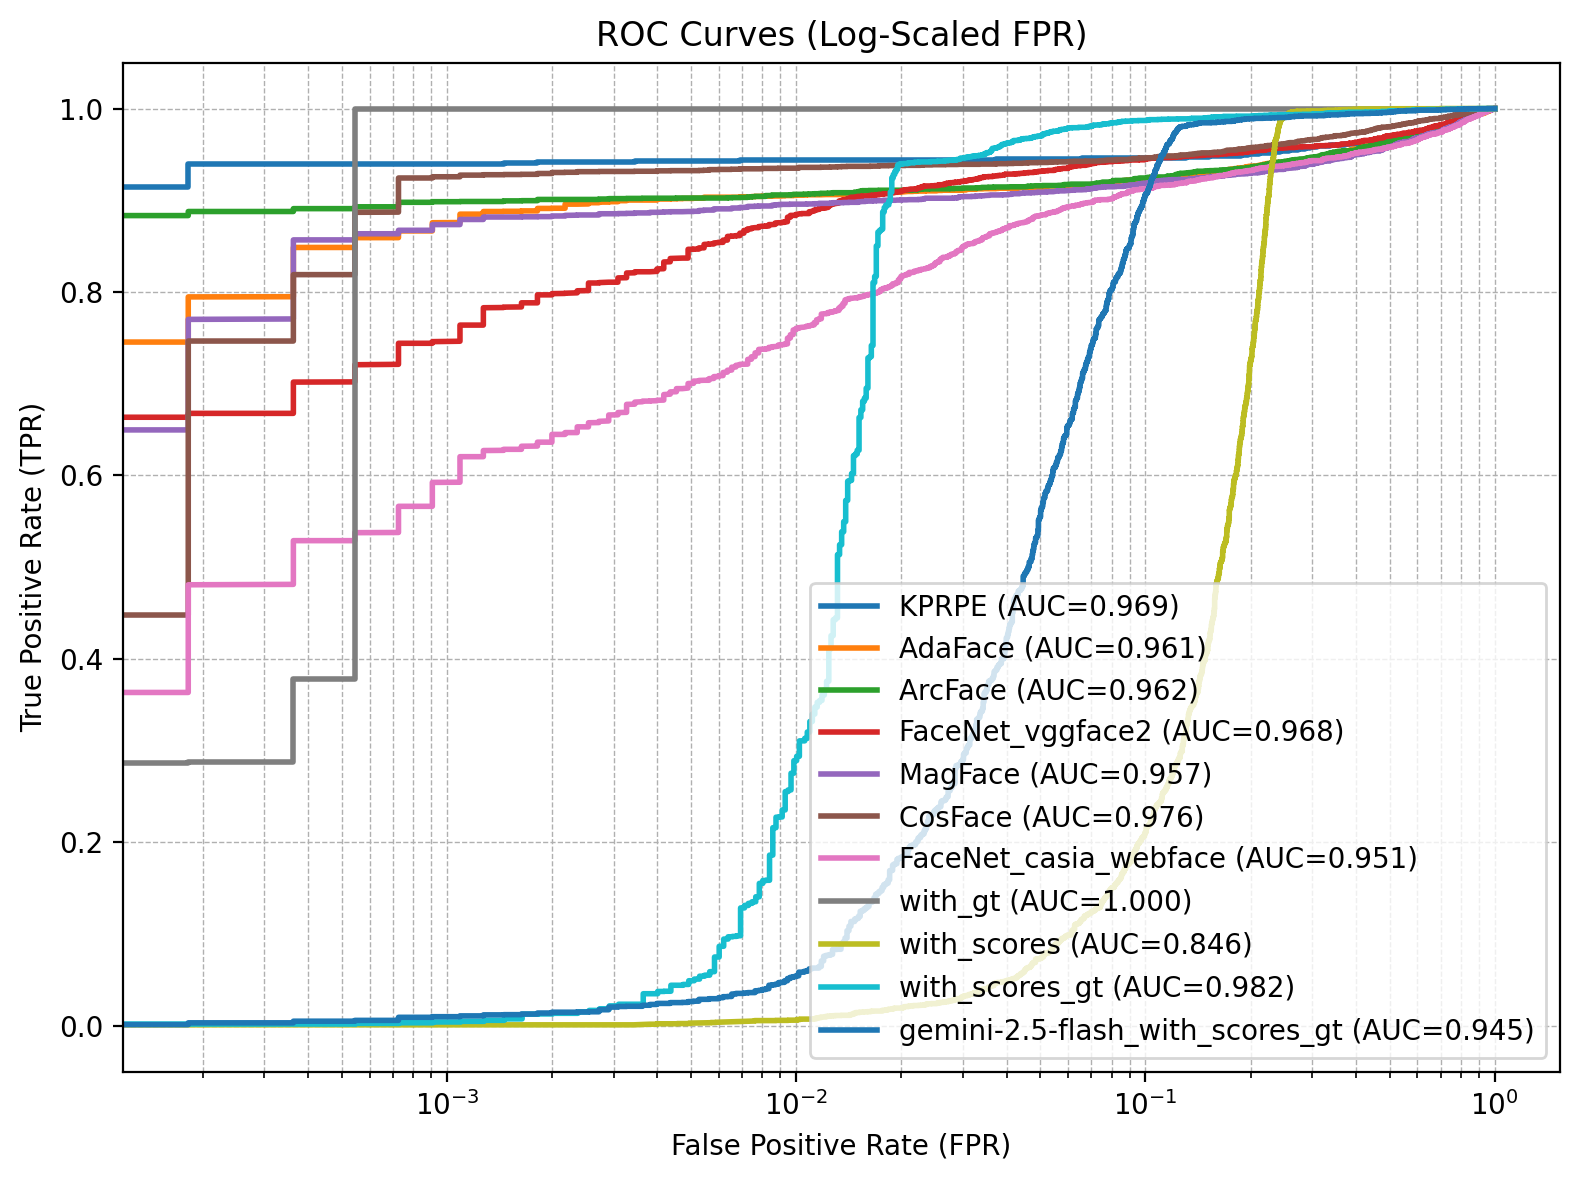

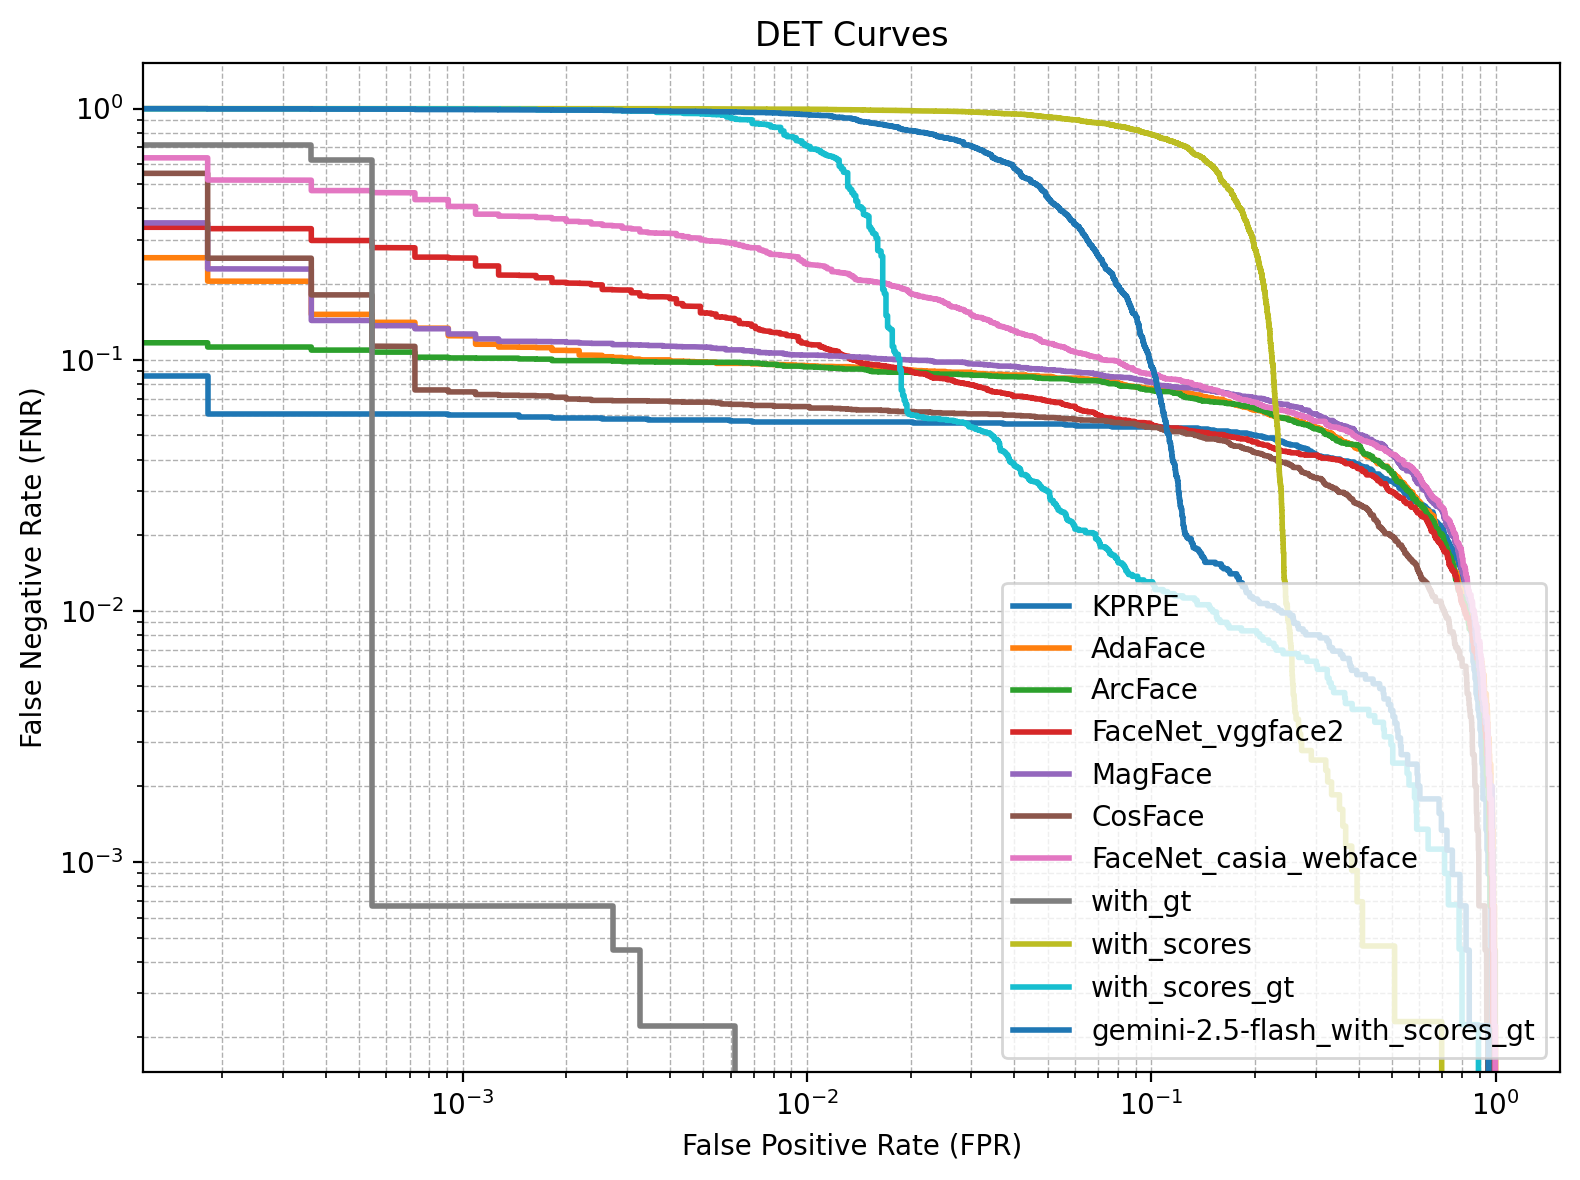

In [7]:






# ============================================================
# 📈 ROC Curve Plot (log-scale FPR)
# ============================================================
plt.figure(figsize=(8, 6), dpi=200)

for model in MODELS:
    plt.plot(fpr_dict[model], tpr_dict[model], lw=2, label=f"{model} (AUC={results_df.loc[model, 'AUC']:.3f})")

plt.xscale("log")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curves (Log-Scaled FPR)")
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()



# ============================================================
# 📉 DET Curve (log-log)
# ============================================================
plt.figure(figsize=(8, 6), dpi=200)

for model in MODELS:
    fpr = fpr_dict[model]
    fnr = 1 - tpr_dict[model]
    plt.plot(fpr, fnr, lw=2, label=model)

plt.xscale("log")
plt.yscale("log")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("False Negative Rate (FNR)")
plt.title("DET Curves")
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


df_results_path = ".data/IJBS/ijbs_still_benchmark_results.csv"
results_df.to_csv(df_results_path)

In [11]:
results_df

,AUC,AP,EER,TMR@FMR=0.1%,TMR@FMR=0.01%,TMR@FMR=0.001%,THR@FMR=0.1%,THR@FMR=0.01%,THR@FMR=0.001%
KPRPE,0.969160,0.978478,0.055008,0.940062,0.914439,0.914439,0.293876,0.514216,0.514216
AdaFace,0.961566,0.971352,0.080411,0.875891,0.745544,0.745544,0.303900,0.446200,0.446200
ArcFace,0.962098,0.971816,0.079511,0.898619,0.883467,0.883467,0.298400,0.398000,0.398000
FaceNet_vggface2,0.968018,0.975996,0.062425,0.746435,0.663547,0.663547,0.623400,0.672200,0.672200
MagFace,0.956561,0.968055,0.084614,0.873663,0.649733,0.649733,0.348500,0.544900,0.544900
CosFace,0.975855,0.981318,0.057908,0.925802,0.447861,0.447861,0.328100,0.730500,0.730500
FaceNet_casia_webface,0.951519,0.960889,0.090010,0.592692,0.363414,0.363414,0.616900,0.745800,0.745800


In [12]:
results_df.to_csv(".data/IJBS/ijbs_still_benchmark_results.csv")

In [37]:
df_scores = pd.read_csv(".data/IJBS/ijbs_still_benchmark_scores.csv")
df_result = pd.read_csv(".data/IJBS/ijbs_still_benchmark_results.csv")

MODELS = [
    'KPRPE', 'AdaFace', 'ArcFace', 'FaceNet_vggface2',
    'MagFace', 'CosFace', 'FaceNet_casia_webface'
]

In [ ]:
import json
def evaluate_row(row, thresholds, models):
    res = {}
    for model in models:
        score = row[model]
        status = "Match" if score >= thresholds[model] else "Non-Match"
        res[model] = (round(score, 2), status)
    return res

MODELS = results_df.index.tolist()



for index, row in df_scores.iterrows():
    eval_result = evaluate_row(row, THRESHOLDS, MODELS)
    
    print(json.dumps(eval_result, indent=2))
    break




{
  "KPRPE": [
    0.81,
    "Match"
  ],
  "AdaFace": [
    0.51,
    "Match"
  ],
  "ArcFace": [
    0.74,
    "Match"
  ],
  "FaceNet_vggface2": [
    0.79,
    "Match"
  ],
  "MagFace": [
    0.63,
    "Match"
  ],
  "CosFace": [
    0.76,
    "Match"
  ],
  "FaceNet_casia_webface": [
    0.77,
    "Match"
  ]
}


In [1]:
print("Evaluation complete.")

Evaluation complete.


In [9]:
import glob

def extract_and_validate(text):
    
    # Split the text into lines first
    lines = text.split('\n')

    # Find the line in which "Match Verdict:" appears
    match_verdict_line = next((i for i, line in enumerate(lines) if "Match Verdict:" in line), None)
    if match_verdict_line is None:
        return False, "Error: 'Match Verdict:' section not found." 

    for i, line in enumerate(lines):
        if "Match Verdict:" in line:
            match_verdict_line = i
        if "Similarities:" in line:
            similarities_line = i
        if "Differences:" in line:
            differences_line = i
        if "Overall Reasoning:" in line:
            overall_reasoning_line = i
    try:
        if (similarities_line+6)  == differences_line + 3 == overall_reasoning_line:
            return True, "\n".join(lines[match_verdict_line:overall_reasoning_line + 2])
        else: 
            return False, f"Error: Section formatting issue."
    except:
        return False, f"Error: Section formatting issue."
        


EXPLANATION_DIRECTORY = ".data/IJBS/Explanations-with-scores-gt/gpt-4o"

exp_paths = glob.glob(f"{EXPLANATION_DIRECTORY}/*.txt")
print(f"Found {len(exp_paths)} explanation files." )


# Read the each of the files and see if it has the word 'unable' in the first line
unable_files, parsed_files =  [], []


for path in exp_paths:
    with open(path, 'r') as file:
        first_line = file.readline().strip().lower()
        if 'unable' in first_line:
            unable_files.append(path.split('/')[-1])

        okay, content = extract_and_validate(file.read())
        if okay:
            parsed_files.append(path.split('/')[-1])

print(len(unable_files), "files contain 'unable' in the first line.")



Found 9986 explanation files.
548 files contain 'unable' in the first line.


In [10]:
parsed_files.sort()

In [11]:
len(parsed_files)

9934

In [3]:
import pandas as pd 


df = pd.read_csv(".data/IJBS/ijbs_still_benchmark_scores.csv")
df.drop("LLR_gt", axis=1, inplace=True)
df.to_csv(".data/IJBS/ijbs_still_benchmark_scores.csv", index=False)

In [4]:
df

,pair_id,image1,image2,id1,id2,label,part,gpt-4o-mini,KPRPE,AdaFace,ArcFace,FaceNet_vggface2,MagFace,CosFace,FaceNet_casia_webface,LLR_Explanation,with_scores_gt,with_scores,with_gt
0,pair_00000,1/img_101146.jpg,1/img_101147.jpg,1,1,1,A,0.419272,0.807095,0.5052,0.7370,0.7914,0.6275,0.7625,0.7665,0.594031,0.534459,0.567352,0.594031
1,pair_00001,1/img_101146.jpg,1/img_101148.jpg,1,1,1,A,0.397728,0.686863,0.4741,0.6406,0.7821,0.5983,0.7031,0.5931,0.639733,0.483608,0.817973,0.639733
2,pair_00002,1/img_101146.jpg,1/img_101149.jpg,1,1,1,A,0.384842,0.650281,0.4924,0.6222,0.7672,0.5558,0.6982,0.5925,0.692279,0.554651,0.572612,0.692279
3,pair_00003,1/img_101146.jpg,1/img_101150.jpg,1,1,1,A,0.536775,0.643914,0.4508,0.5824,0.7380,0.5199,0.6572,0.6015,0.621508,0.517712,0.475968,0.621508
4,pair_00004,1/img_101146.jpg,1/img_101151.jpg,1,1,1,A,0.469040,0.641198,0.5100,0.6479,0.7160,0.5720,0.6975,0.4625,0.668449,0.568481,0.453045,0.668449
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9994,pair_09995,17/img_101260.jpg,143/img_100445.jpg,17,143,0,C,0.234700,0.090105,0.0510,0.0174,0.2239,0.0078,0.0197,0.1091,0.215952,0.166917,0.179446,0.215952
9995,pair_09996,149/img_100490.jpg,191/img_100937.jpg,149,191,0,C,0.199733,-0.129117,-0.0358,-0.0870,-0.0098,-0.0702,-0.0707,0.2063,0.183711,0.170037,0.162285,0.183711
9996,pair_09997,149/img_100493.jpg,211/img_100796.jpg,149,211,0,C,0.124588,0.053942,0.0613,0.1182,0.0721,-0.0079,0.0353,0.1204,0.195869,0.164596,0.164498,0.195869
9997,pair_09998,89/img_100062.jpg,111/img_100221.jpg,89,111,0,C,0.325909,0.003555,0.0410,-0.0284,0.1530,0.0562,0.0324,0.1832,0.236057,0.202584,0.617541,0.236057


In [4]:
import pandas as pd
df = pd.read_csv("results/openai/tSNEs/ijbs_cluster_separation_metrics.csv")

# Keep only the rows that has the word "small" in the column embedding_model
df = df[df['embedding_model'].str.contains("small")]

# sort by silhouette_score in descending order
df = df.sort_values(by="silhouette", ascending=False)

# Display the dataframe 
# df

# ROund the datafreame values to 2 decimal places
df.round(2)


,silhouette,davies_bouldin,calinski_harabasz,inter_intra_ratio,fisher_ratio,experiment,gen_model,embedding_model
1,0.30,1.38,4677.57,1.43,1.00,with-gt,gpt-4o,text-embedding-3-small
9,0.28,1.49,4078.40,1.40,0.86,with-kprpe-score-decision,gpt-4o,text-embedding-3-small
5,0.25,1.65,3370.05,1.34,0.71,with-scores-gt,gpt-4o,text-embedding-3-small
6,0.24,1.62,3358.18,1.31,0.72,with-scores-gt,gemini-2.5-flash,text-embedding-3-small
11,0.22,1.76,2837.58,1.27,0.61,with-no-info,gpt-4o,text-embedding-3-small
3,0.18,2.13,1936.36,1.21,0.41,with-scores,gpt-4o,text-embedding-3-small


In [ ]:


result_paths = glob(result_file_pattern)
result_paths

df = pd.read_csv(result_paths[0])
df.head()
exp_name = result_paths[0].split("/")[-3]

y_true = df['label'].to_numpy()
y_scores = df['LLR_Score_Normalized'].to_numpy()

# Now plot the ROC curve


,pair_id,image1,image2,id1,id2,label,part,gpt-4o-mini,KPRPE,AdaFace,...,FaceNet_vggface2,MagFace,CosFace,FaceNet_casia_webface,with_gt,with_scores,with_scores_gt,ROC,LLR_Score,LLR_Score_Normalized
0,pair_00000,1/img_101146.jpg,1/img_101147.jpg,1,1,1,A,0.419272,0.807095,0.5052,...,0.7914,0.6275,0.7625,0.7665,0.594031,0.567352,0.534459,0.990009,895.342551,0.857011
1,pair_00001,1/img_101146.jpg,1/img_101148.jpg,1,1,1,A,0.397728,0.686863,0.4741,...,0.7821,0.5983,0.7031,0.5931,0.639733,0.817973,0.483608,0.972353,481.394878,0.723680
2,pair_00002,1/img_101146.jpg,1/img_101149.jpg,1,1,1,A,0.384842,0.650281,0.4924,...,0.7672,0.5558,0.6982,0.5925,0.692279,0.572612,0.554651,0.827101,1181.216517,0.913917
3,pair_00003,1/img_101146.jpg,1/img_101150.jpg,1,1,1,A,0.536775,0.643914,0.4508,...,0.7380,0.5199,0.6572,0.6015,0.621508,0.475968,0.517712,0.768669,1117.024943,0.903266
4,pair_00004,1/img_101146.jpg,1/img_101151.jpg,1,1,1,A,0.469040,0.641198,0.5100,...,0.7160,0.5720,0.6975,0.4625,0.668449,0.453045,0.568481,0.763890,877.014660,0.852460


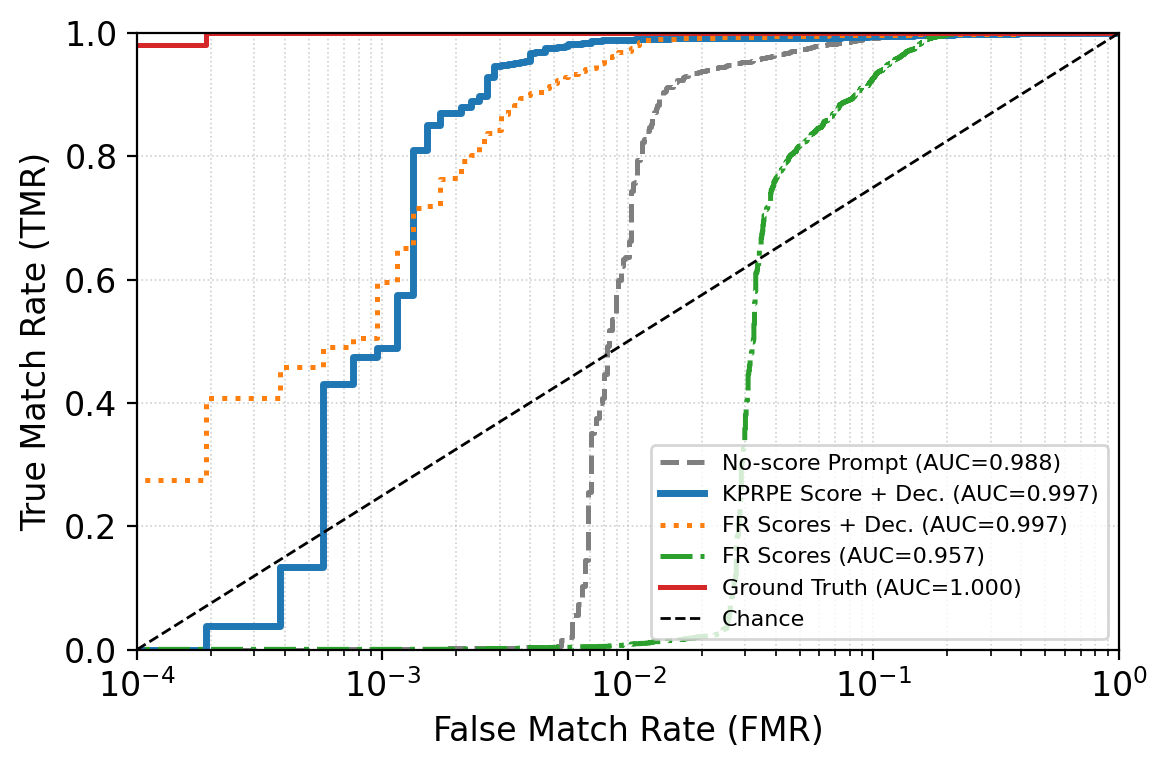

In [27]:
name_map = {
    "with-no-info": "No-score Prompt",
    "with-kprpe-score-decision": "KPRPE Score + Dec.",
    "with-scores-gt": "FR Scores + Dec.",
    "with-scores": "FR Scores",
    "with-gt": "Ground Truth",
}
style_map = {
    "with-no-info": dict(color="#7f7f7f", linestyle="--", linewidth=1.8),   # gray dashed
    "with-kprpe-score-decision": dict(color="#1f77b4", linestyle="-", linewidth=2.5),  # blue solid (highlight)
    "with-scores-gt": dict(color="#ff7f0e", linestyle=":", linewidth=1.8),  # orange dotted
    "with-scores": dict(color="#2ca02c", linestyle="-.", linewidth=1.8),    # green dash-dot
    "with-gt": dict(color="#d62728", linestyle="-", linewidth=1.8),          # red solid
}



from glob import glob
result_file_pattern = "results/lr-eval/*/gpt-4o_text-embedding-3-small/test_scores.csv"



import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(6, 4), dpi=200)

for path in result_paths:
    df = pd.read_csv(path)

    exp_key = path.split("/")[-3]
    exp_name = name_map.get(exp_key, exp_key)
    style = style_map.get(exp_key, dict(color="black", linestyle="-", linewidth=1.5))

    y_true = df['label'].to_numpy()
    y_scores = df['LLR_Score_Normalized'].to_numpy()

    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{exp_name} (AUC={roc_auc:.3f})",
        **style
    )

# Chance line (clearly different)
plt.plot(
    [1e-4, 1], [0, 1],
    color="black",
    linestyle="--",
    linewidth=1,
    label="Chance"
)

# Biometrics-style axes
plt.xscale("log")
plt.xlim([1e-4, 1.0])
plt.ylim([0.0, 1.0])

plt.xlabel("False Match Rate (FMR)")
plt.ylabel("True Match Rate (TMR)")
# plt.title("ROC Curves Across Prompting Strategies")

plt.legend(loc="lower right", fontsize=8, frameon=True)
plt.grid(True, which="both", linestyle=":", linewidth=0.6, alpha=0.6)

plt.tight_layout()
plt.savefig("results/lr-eval/roc_comparison.png", dpi=150)
plt.show()

In [15]:
# Print experiment names
for path in result_paths:
    exp_name = path.split("/")[-3]
    print(exp_name)

with-no-info
with-kprpe-score-decision
with-scores-gt
with-scores
with-gt


Experiment: with-no-info


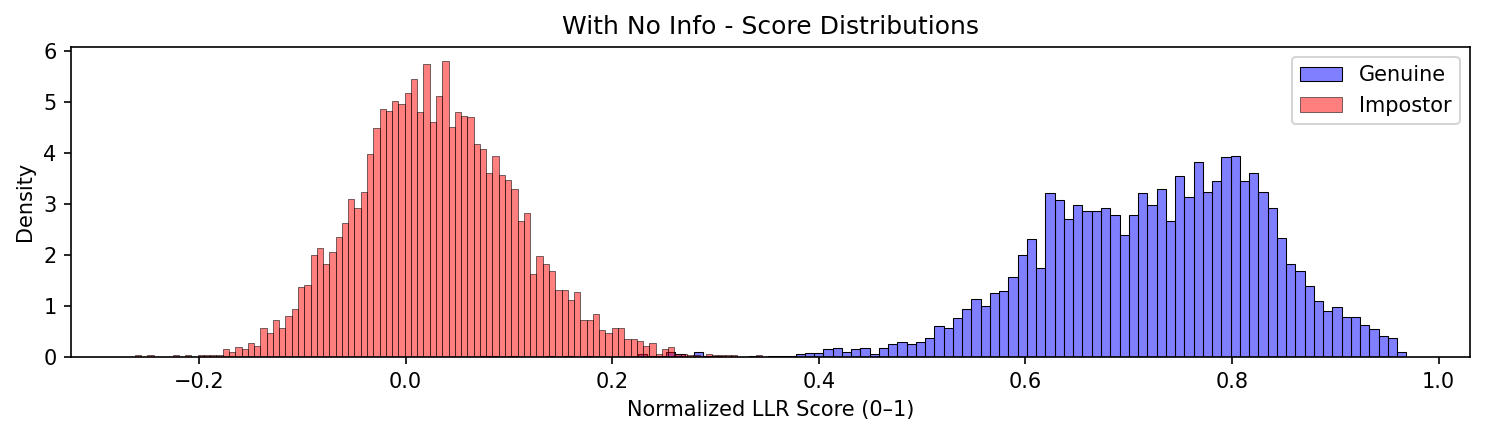

In [36]:
from glob import glob
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

paths= glob("results/lr-eval/*/gpt-4o_text-embedding-3-small/test_scores.csv")
experiment_name = paths[0].split("/")[-3]
print("Experiment:", experiment_name)
df = pd.read_csv(paths[0])

dpi = 150
title = experiment_name.replace("-", " ").title() + " - Score Distributions"
# y_pred = (df['KPRPE'] + df['LLR_Score_Normalized']).to_numpy()/2
y_pred = df['KPRPE'].to_numpy()
y_val = df['label'].to_numpy()

plt.figure(figsize=(10, 3), dpi=dpi)

sns.histplot(y_pred[y_val == 1], label='Genuine',
                stat='density', bins=100, kde=False, color='blue', alpha=0.5)
sns.histplot(y_pred[y_val == 0], label='Impostor',
                stat='density', bins=100, kde=False, color='red', alpha=0.5)

plt.title(title)
plt.xlabel('Normalized LLR Score (0–1)')
plt.ylabel('Density')
plt.legend()
# plt.grid(True)
plt.tight_layout()


label
0    339
1    146
Name: count, dtype: int64


Text(0, 0.5, 'Count')

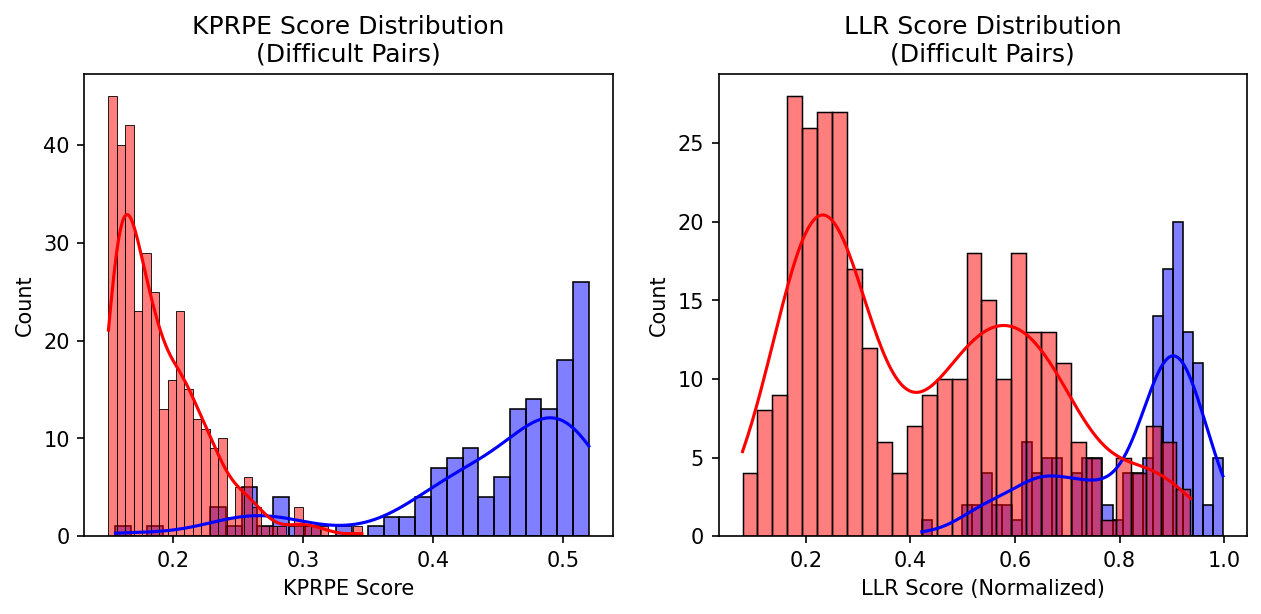

In [37]:
# Find the rows of KPRPE scores that are threshsold +-0.05 around 0.514 
threshold = 0.5
upper_threshold = 0.52
lower_threshold = 0.15

df_difficult = df[(df['KPRPE'] >= lower_threshold) & (df['KPRPE'] <= upper_threshold)]
print(df_difficult['label'].value_counts())
# Now in two plots side by side, plot the score distributions of KPRPE and LLR_Score_Normalized for the rows that are in the threshold range.

df_difficult.head()

fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=150)
sns.histplot(df_difficult[df_difficult['label'] == 1]['KPRPE'], bins=30, kde=True, ax=axes[0], color='blue', label='Genuine')
sns.histplot(df_difficult[df_difficult['label'] == 0]['KPRPE'], bins=30, kde=True, ax=axes[0], color='red', label='Impostor')
axes[0].set_title('KPRPE Score Distribution\n(Difficult Pairs)')
axes[0].set_xlabel('KPRPE Score')
axes[0].set_ylabel('Count') 

sns.histplot(df_difficult[df_difficult['label'] == 1]['LLR_Score_Normalized'], bins=30, kde=True, ax=axes[1], color='blue', label='Genuine')
sns.histplot(df_difficult[df_difficult['label'] == 0]['LLR_Score_Normalized'], bins=30, kde=True, ax=axes[1], color='red', label='Impostor')
axes[1].set_title('LLR Score Distribution\n(Difficult Pairs)')
axes[1].set_xlabel('LLR Score (Normalized)')
axes[1].set_ylabel('Count')

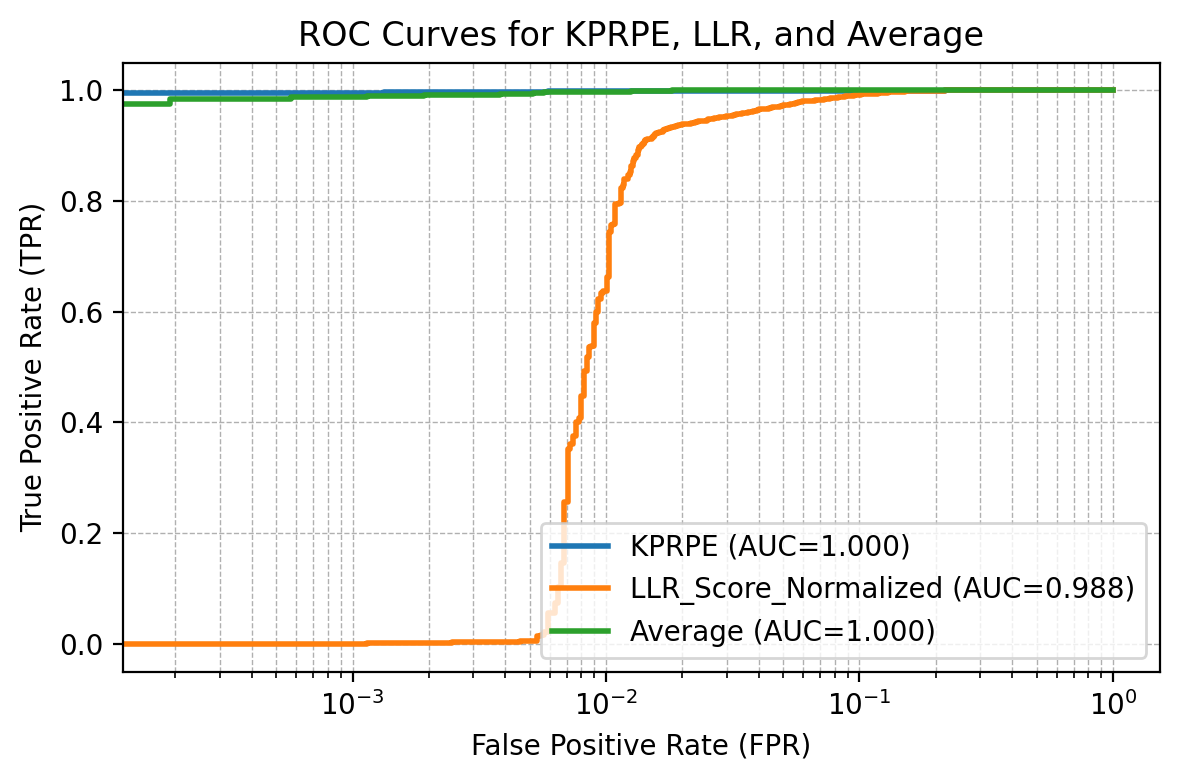

In [11]:
# Plot the ROC curve for both KPRPE, LLR_Score_Normalized and their average
plt.figure(figsize=(6, 4), dpi=200)
from sklearn.metrics import roc_curve, auc
labels = df['label'].to_numpy()
for model in ["KPRPE", "LLR_Score_Normalized"]:
    fpr, tpr, _ = roc_curve(labels, df[model].to_numpy())
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"{model} (AUC={roc_auc:.3f})")

# Plot ROC for the average of both models
avg_scores = (df["KPRPE"] + df["LLR_Score_Normalized"]) / 2
fpr, tpr, _ = roc_curve(labels, avg_scores.to_numpy())
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, lw=2, label=f"Average (AUC={roc_auc:.3f})")

plt.xscale("log")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curves for KPRPE, LLR, and Average")
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend(loc='lower right')
plt.tight_layout()

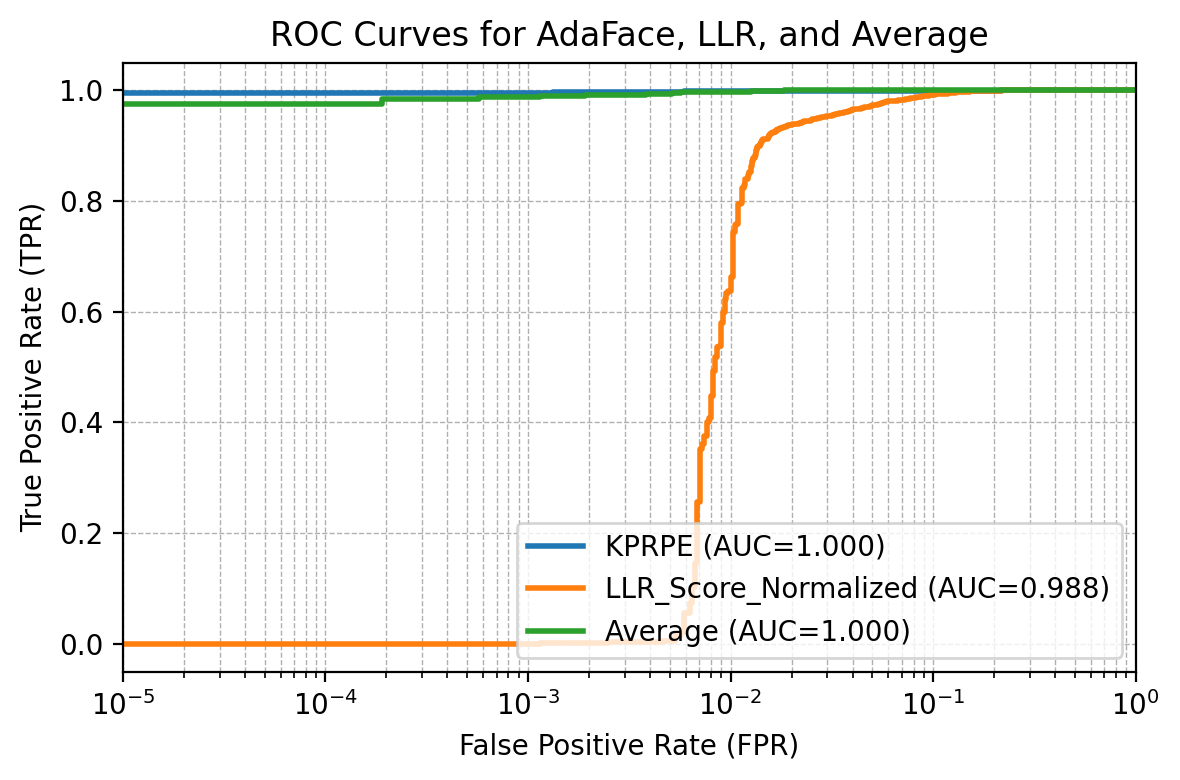

In [14]:
# Plot the ROC curve for both KPRPE, LLR_Score_Normalized and their average
plt.figure(figsize=(6, 4), dpi=200)
from sklearn.metrics import roc_curve, auc

labels = df['label'].to_numpy()

for model in ["KPRPE", "LLR_Score_Normalized"]:
    fpr, tpr, _ = roc_curve(labels, df[model].to_numpy())
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"{model} (AUC={roc_auc:.3f})")

# ROC for the average of both models
avg_scores = (df["KPRPE"] + df["LLR_Score_Normalized"]) / 2
fpr, tpr, _ = roc_curve(labels, avg_scores.to_numpy())
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, lw=2, label=f"Average (AUC={roc_auc:.3f})")

# Log-scale FPR and limit to 1e-5
plt.xscale("log")
plt.xlim([1e-5, 1.0])

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curves for AdaFace, LLR, and Average")
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [3]:
import torch
import yaml
# from my_model_file import MyModelClass  # must match original code

MODEL_PATH = "/mnt/research/iPRoBeLab/sonymd/LikelihoodRatio/fr_models/adaface_vit_base_kprpe_webface4m/model.yaml"
MODEL_WEIGHTS_PATH = "/mnt/research/iPRoBeLab/sonymd/LikelihoodRatio/fr_models/adaface_vit_base_kprpe_webface4m/model.pt"

# load configuration
with open(MODEL_PATH, "r") as f:
    config = yaml.safe_load(f)

config
# # initialize model using config
# model = MyModelClass(**config['model_params'])

# # load weights
# state_dict = torch.load(MODEL_WEIGHTS_PATH, map_location="cpu")
# model.load_state_dict(state_dict)

# model.eval()

{'input_size': [3, 112, 112],
 'color_space': 'RGB',
 'name': 'base',
 'output_dim': 512,
 'start_from': '',
 'freeze': False,
 'mask_ratio': 0.0,
 'rpe_config': {'name': 'KPRPE_shared',
  'rpe_on': 'k',
  'shared_head': True,
  'mode': 'ctx',
  'method': 'product',
  'ratio': 1.9,
  'ctx_type': 'rel_keypoint_splithead_unshared',
  'num_keypoints': 5},
 'yaml_path': 'models/vit_kprpe/configs/v1_base_kprpe_splithead_unshared.yaml'}

TMR at FMR=0.01%: 0.7822, AUC: 0.9862


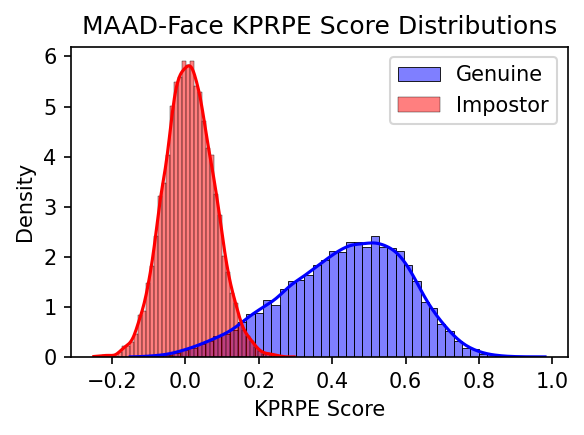

In [1]:
import pandas as pd
from sklearn.metrics import roc_curve, auc
import seaborn as sns
import matplotlib.pyplot as plt
import random
import numpy as np

# Sample 4000 rows from the IJBS dataset for faster plotting
maadface_dataset_metadata_path = ".data/MAAD-Face/metadata/maadface_test_pairs_with_kprpe_scores.csv"
df_maadface = pd.read_csv(maadface_dataset_metadata_path)
df_maadface.head()


# Plot the score distribution for the MAAD-Face dataset with label coming from the 'label' column

plt.figure(figsize=(4, 3), dpi=150)
sns.histplot(df_maadface[df_maadface['Label'] == 1]['kprpe_score'], label='Genuine', stat='density', bins=50, kde=True, color='blue', alpha=0.5)
sns.histplot(df_maadface[df_maadface['Label'] == 0]['kprpe_score'], label='Impostor', stat='density', bins=50, kde=True, color='red', alpha=0.5)
plt.title('MAAD-Face KPRPE Score Distributions')
plt.xlabel('KPRPE Score')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()



# Now compute the TMR at 0.01% FMR for the KPRPE scores on this MAAD-Face sample
labels = df_maadface['Label'].to_numpy()
scores = df_maadface['kprpe_score'].to_numpy()
fpr, tpr, thresholds = roc_curve(labels, scores)
roc_auc = auc(fpr, tpr)

# Compute TMR at 0.01% FMR
target_fmr = 1e-4
idx = np.searchsorted(fpr, target_fmr, side="left")
if idx >= len(fpr):
    tmr_at_target_fmr = tpr[-1]
else:
    tmr_at_target_fmr = tpr[idx]
print(f"TMR at FMR=0.01%: {tmr_at_target_fmr:.4f}, AUC: {roc_auc:.4f}")

In [4]:
df_maadface['kprpe_score'].describe()

# Calculate min and max of the kprpe_score column and normalize the scores to be between 0 and 1 using min-max normalization
min_score = df_maadface['kprpe_score'].min()
max_score = df_maadface['kprpe_score'].max()
print(f"Min KPRPE Score: {min_score:.4f}, Max KPRPE Score: {max_score:.4f}")

Min KPRPE Score: -0.2492, Max KPRPE Score: 0.9797


In [ ]:
from ClusterSeparability import compute_cluster_separability_metrics


compute_cluster_separability_metrics()

In [12]:
maadface_dataset_metadata_path = ".data/MAAD-Face/metadata/maadface_test_pairs_with_kprpe_scores.csv"
df_maadface = pd.read_csv(maadface_dataset_metadata_path)
df_maadface.head()

# Here out of the total length, the first half are the genuine pairs and the second half are the impostor pairs. 
# Randomize the rows first 
df_maadface = df_maadface.sample(frac=1, random_state=42).reset_index(drop=True)




In [17]:
# Create a pair_id column with format pair_00002 for each row
df_maadface['pair_id'] = df_maadface.index.to_series().apply(lambda x: f"pair_{x:05d}")
# Now put the pair_id column as the first column in the dataframe
cols = df_maadface.columns.tolist()
cols = ['pair_id'] + [col for col in cols if col != 'pair_id']
df_maadface = df_maadface[cols]
df_maadface.head()

# Update the same datafralme
df_maadface.to_csv(".data/MAAD-Face/metadata/maadface_test_pairs_with_kprpe_scores.csv", index=False)



In [41]:
data_path = ".data/MAAD-Face/metadata/maadface_test_pairs_with_kprpe_scores.csv"
df = pd.read_csv(data_path)

# Now I have 20000 filenames. Split them into 10 equal parts and save each part into a separate csv file.
num_parts = 10
part_size = len(df) // num_parts
for i in range(num_parts):
    start_idx = i * part_size
    end_idx = (i + 1) * part_size if i < num_parts - 1 else len(df)
    df_part = df.iloc[start_idx:end_idx]
    df_part.to_csv(f".data/MAAD-Face/metadata/maadface_test_pairs_with_kprpe_scores_part_{i+1}.csv", index=False)

In [14]:
import pandas as pd
import glob 
import os

files = glob.glob(".data/MAAD-Face/metadata/maadface_test_pairs_with_kprpe_scores_part_*.csv")

# Sort files based on the part number
files.sort(key=lambda x: int(x.split("_")[-1].split(".")[0]))

total_completed, total_missing = 0, 0
for file_path in files:
    df_part = pd.read_csv(file_path)
    
    exists, missing = 0, 0
    for pair_id in df_part['pair_id']:
        if os.path.exists(f".data/MAAD-Face/Explanations/with-no-info/Qwen3-VL-30B-A3B-Instruct/{pair_id}.txt"):
            exists += 1
        else:
            missing += 1
    total_completed += exists
    total_missing += missing

    part = file_path.split("_")[-1].split(".")[0]
    # Prepare the print in fixed width format
    print(f"Part {part:<2} : Completed:{exists:<5} \t Remaining: {missing:<5}" )
print(f"Total Completed: {total_completed} \t Total Remaining: {total_missing}, Percentage Completed: {total_completed/(total_completed+total_missing)*100:.2f}%")

Part 1  : Completed:2000  	 Remaining: 0    
Part 2  : Completed:2000  	 Remaining: 0    
Part 3  : Completed:2000  	 Remaining: 0    
Part 4  : Completed:2000  	 Remaining: 0    
Part 5  : Completed:2000  	 Remaining: 0    
Part 6  : Completed:2000  	 Remaining: 0    
Part 7  : Completed:2000  	 Remaining: 0    
Part 8  : Completed:2000  	 Remaining: 0    
Part 9  : Completed:2000  	 Remaining: 0    
Part 10 : Completed:2000  	 Remaining: 0    
Total Completed: 20000 	 Total Remaining: 0, Percentage Completed: 100.00%


In [ ]:
from openai import OpenAI
client = OpenAI()

response = client.responses.create(
    model="gpt-5.2",
    input="How much gold would it take to coat the Statue of Liberty in a 1mm layer?",
    reasoning={
        "effort": "high"
    }
)



In [12]:
print(response.output[0].content[0].text)

Approximate it by treating the Statue of Liberty’s exterior surface area as about **18,000 m²** (a commonly cited figure for the copper skin).

A **1 mm** layer is **0.001 m** thick, so the gold volume needed is:

- **Volume = area × thickness = 18,000 m² × 0.001 m = 18 m³**

Gold’s density is about **19,320 kg/m³**, so the mass is:

- **Mass = 18 m³ × 19,320 kg/m³ ≈ 347,760 kg**

So it would take about **3.5 × 10⁵ kg of gold** (≈ **350 metric tons**).

As a sense-check, that’s about:

- **~11.2 million troy ounces** (since 1 troy oz ≈ 31.1035 g)

This ignores small geometric details and assumes a uniform 1 mm layer over the full exterior surface.


In [ ]:
# Limit CPUs to use only 4 threads
import os
os.environ["OMP_NUM_THREADS"] = "4"
os.environ["OPENBLAS_NUM_THREADS"] = "4"
os.environ["MKL_NUM_THREADS"] = "4"
os.environ["VECLIB_MAXIMUM_THREADS"] = "4"
os.environ["NUMEXPR_NUM_THREADS"] = "4"

# Now I want to perform tSNE plot on the embeddings of the files. 
import pandas as pd
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
df = pd.read_csv(".data/MAAD-Face/metadata/maadface_test_pairs_with_kprpe_scores.csv")
df.set_index("pair_id", inplace=True)



stored_data = np.load(".data/MAAD-Face/Explanations/with-no-info/Qwen3-VL-30B-A3B-Instruct_embeddings/explanation_embeddings.npz", allow_pickle=True)

# 
embeddings = stored_data['embeddings']
pair_ids = stored_data['pair_ids']
labels = df.loc[pair_ids, 'Label'].to_numpy()



In [18]:

# Perform tSNE on the embeddings
tsne = TSNE(n_components=2, random_state=42, n_jobs=4)
embeddings_2d = tsne.fit_transform(embeddings)

In [29]:
# 5-fold cross validation using Logistic Regression

import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold


# Your data
X = embeddings   # shape (N, D)
y = labels       # shape (N,)


# Create 5-fold cross validation object
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=1455
)


accuracies = []


# Perform cross-validation
for fold, (train_idx, test_idx) in enumerate(kf.split(X)):

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]


    # Create classifier
    clf = LogisticRegression(
        max_iter=500,
        solver="lbfgs"
    )


    # Train
    clf.fit(X_train, y_train)


    # Predict
    y_pred = clf.predict(X_test)


    # Compute accuracy
    acc = accuracy_score(y_test, y_pred)

    accuracies.append(acc)


    print(f"Fold {fold+1} Accuracy: {acc:.4f}")


# Average accuracy
avg_accuracy = np.mean(accuracies)
std_accuracy = np.std(accuracies)

print("\nFinal Results:")
print(f"Average Accuracy: {avg_accuracy:.4f} ± {std_accuracy:.4f}")

Fold 1 Accuracy: 0.9340
Fold 2 Accuracy: 0.9327
Fold 3 Accuracy: 0.9277
Fold 4 Accuracy: 0.9312
Fold 5 Accuracy: 0.9332

Final Results:
Average Accuracy: 0.9318 ± 0.0022


In [1]:
import glob
import pandas as pd
import os

experiment_name = "with-kprpe-score"
metadata_files = glob.glob(f".data/MAAD-Face/metadata/maadface_test_pairs_with_kprpe_scores_part_*.csv")
metadata_files.sort(key=lambda x: int(x.split("_")[-1].split(".")[0]))
metadata_files	

for file in metadata_files:
	df_part = pd.read_csv(file)
	exists, missing = 0, 0
	pair_ids = df_part['pair_id'].tolist()
	for pair_id in pair_ids:
		explanation_path = f".data/MAAD-Face/Explanations/{experiment_name}/Qwen3-VL-30B-A3B-Instruct/{pair_id}.txt"
		if not os.path.exists(explanation_path):
			missing += 1
		else:
			exists += 1
	part_num = file.split("_")[-1].split(".")[0]
	print(f"Part {part_num}: Completed: {exists} \t Remaining: {missing}")

Part 1: Completed: 2000 	 Remaining: 0
Part 2: Completed: 2000 	 Remaining: 0
Part 3: Completed: 2000 	 Remaining: 0
Part 4: Completed: 2000 	 Remaining: 0
Part 5: Completed: 2000 	 Remaining: 0
Part 6: Completed: 2000 	 Remaining: 0
Part 7: Completed: 1994 	 Remaining: 6
Part 8: Completed: 1968 	 Remaining: 32
Part 9: Completed: 2000 	 Remaining: 0
Part 10: Completed: 2000 	 Remaining: 0


In [ ]:
EVALUATION_PATH = "QWEN/.data/MAAD-Face/Evaluations"
# EXPERIMENT_NAME = "with-no-info"
EXPERIMENT_NAME = "with-kprpe-score"
MODEL_NAME = "Qwen3-VL-30B-A3B-Instruct"
evaluation_files = glob.glob(f"{EVALUATION_PATH}/{EXPERIMENT_NAME}/{MODEL_NAME}/*.json")
print(f"Found {len(evaluation_files)} evaluation files for experiment '{EXPERIMENT_NAME}'.")

import json

scores = []
violations = []
for eval_file in evaluation_files:

	with open(eval_file, 'r') as f:
		eval_data = json.load(f)
		eval_data
		scores.append(eval_data['total_score'])
		violations.append(len(eval_data['violations']))

# Print the average and standard deviation of the scores
import numpy as np
print(f"Average Score: {np.mean(scores):.4f}, Std Dev: {np.std(scores):.4f} for experiment '{EXPERIMENT_NAME}'")

Found 1805 evaluation files for experiment 'with-kprpe-score'.


In [24]:
evaluation_files[:5]

['QWEN/.data/MAAD-Face/Evaluations/with-kprpe-score/Qwen3-VL-30B-A3B-Instruct/pair_01143_eval.json',
 'QWEN/.data/MAAD-Face/Evaluations/with-kprpe-score/Qwen3-VL-30B-A3B-Instruct/pair_00905_eval.json',
 'QWEN/.data/MAAD-Face/Evaluations/with-kprpe-score/Qwen3-VL-30B-A3B-Instruct/pair_01296_eval.json',
 'QWEN/.data/MAAD-Face/Evaluations/with-kprpe-score/Qwen3-VL-30B-A3B-Instruct/pair_01498_eval.json',
 'QWEN/.data/MAAD-Face/Evaluations/with-kprpe-score/Qwen3-VL-30B-A3B-Instruct/pair_00504_eval.json']

Average Score: 7.1452, Std Dev: 2.2153 for experiment 'with-kprpe-score'


In [37]:
import glob
import json
import numpy as np

EVALUATION_PATH = "QWEN/.data/MAAD-Face/Evaluations"
MODEL_NAME = "Qwen3-VL-30B-A3B-Instruct"

def evaluate_experiment(experiment_name, model_name=MODEL_NAME, evaluation_path=EVALUATION_PATH):
    evaluation_files = glob.glob(f"{evaluation_path}/{experiment_name}/{model_name}/*.json")
    
    if not evaluation_files:
        print(f"No evaluation files found for experiment '{experiment_name}'.")
        return None

    print(f"Found {len(evaluation_files)} evaluation files for experiment '{experiment_name}'.")

    scores, violations = [], []
    attribute_accuracies = []
    consistencies = []
    no_contradictions = []

    for eval_file in evaluation_files:
        with open(eval_file, 'r') as f:
            eval_data = json.load(f)
            scores.append(eval_data['total_score'])
            violations.append(len(eval_data['violations']))
            attribute_accuracies.append(eval_data.get('attribute_accuracy', 0))
            consistencies.append(eval_data.get('consistency', 0))
            no_contradictions.append(eval_data.get('no_contradiction', 0))

    results = {
        "experiment_name": experiment_name,
        "num_files": len(evaluation_files),
        "avg_score": np.mean(scores),
        "std_score": np.std(scores),
        "avg_violations": np.mean(violations),
        "total_violations": sum(violations),
        "avg_attribute_accuracy": np.mean(attribute_accuracies),
        "avg_consistency": np.mean(consistencies),
        "avg_no_contradiction": np.mean(no_contradictions)
    }

    print(f"Average Score:           {results['avg_score']:.4f} ± {results['std_score']:.4f}")
    print(f"Average Violations:      {results['avg_violations']:.2f} (Total: {results['total_violations']})")
    print(f"Attribute Accuracy:      {results['avg_attribute_accuracy']:.4f}")
    print(f"Consistency:             {results['avg_consistency']:.4f}")
    print(f"No Contradiction:        {results['avg_no_contradiction']:.4f}")

    return results

In [39]:
result_with_kprpe = evaluate_experiment("with-kprpe-score")
print("\n" + "="*50 + "\n")
result_with_no_info = evaluate_experiment("with-no-info")



Found 4915 evaluation files for experiment 'with-kprpe-score'.
Average Score:           7.1969 ± 2.1522
Average Violations:      2.85 (Total: 14017)
Attribute Accuracy:      1.9194
Consistency:             2.1447
No Contradiction:        3.0690


Found 20000 evaluation files for experiment 'with-no-info'.
Average Score:           7.2744 ± 2.2112
Average Violations:      2.94 (Total: 58727)
Attribute Accuracy:      1.9423
Consistency:             2.1935
No Contradiction:        3.0764
